In [1]:
import pandas as pd

initial_df = pd.read_csv("btcusdt_1h.csv")

final_df = initial_df
initial_df

,datetime,open,high,low,close,volume
0,2018-01-01 05:30:00,13715.65,13715.65,13400.01,13529.01,443.356199
1,2018-01-01 06:30:00,13528.99,13595.89,13155.38,13203.06,383.697006
2,2018-01-01 07:30:00,13203.00,13418.43,13200.00,13330.18,429.064572
3,2018-01-01 08:30:00,13330.26,13611.27,13290.00,13410.03,420.087030
4,2018-01-01 09:30:00,13434.98,13623.29,13322.15,13601.01,340.807329
...,...,...,...,...,...,...
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.601780
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.103800
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.859930
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.142010


# MACD

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import pandas_ta as ta
import math
from ta.trend import MACD

# Assuming you have initial_df already defined with a 'Close' column
# Calculate the RSI indicator for initial_df
macd = MACD(close=initial_df['close'],window_slow = 49 , window_fast = 24 , window_sign = 9, fillna=False)

# Access the RSI values
macd_values = macd.macd_diff()

final_df['macd_vals'] = macd_values
final_df['macd_sig'] = 0
for i in range(len(macd_values)):
  if( np.isnan(macd_values[i])):
    final_df['macd_sig'][i] = 0
  elif(macd_values[i] > 0 ):
    final_df['macd_sig'][i] = 1
  else:
    final_df['macd_sig'][i] = -1



<ipython-input-2-3eeb54bf04b2>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['macd_sig'][i] = 0
<ipython-input-2-3eeb54bf04b2>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['macd_sig'][i] = 1
<ipython-input-2-3eeb54bf04b2>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['macd_sig'][i] = -1


# Aroon


<ipython-input-3-3cd0b4734a7e>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['aroon_sig'][i] = 0
<ipython-input-3-3cd0b4734a7e>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['aroon_sig'][i] = -1
<ipython-input-3-3cd0b4734a7e>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['aroon_sig'][i] = 1


                  datetime      open      high       low     close  \
0      2018-01-01 05:30:00  13715.65  13715.65  13400.01  13529.01   
1      2018-01-01 06:30:00  13528.99  13595.89  13155.38  13203.06   
2      2018-01-01 07:30:00  13203.00  13418.43  13200.00  13330.18   
3      2018-01-01 08:30:00  13330.26  13611.27  13290.00  13410.03   
4      2018-01-01 09:30:00  13434.98  13623.29  13322.15  13601.01   
...                    ...       ...       ...       ...       ...   
35203  2022-01-12 01:30:00  42972.04  43095.26  42692.19  42800.38   
35204  2022-01-12 02:30:00  42797.62  42823.69  42643.74  42659.20   
35205  2022-01-12 03:30:00  42664.71  42776.14  42597.41  42713.13   
35206  2022-01-12 04:30:00  42713.12  42886.28  42633.97  42729.29   
35207  2022-01-12 05:30:00  42729.29  42965.00  42578.02  42675.00   

            volume  macd_vals  macd_sig  aroon_vals  aroon_sig  
0       443.356199        NaN         0         NaN          0  
1       383.697006        NaN

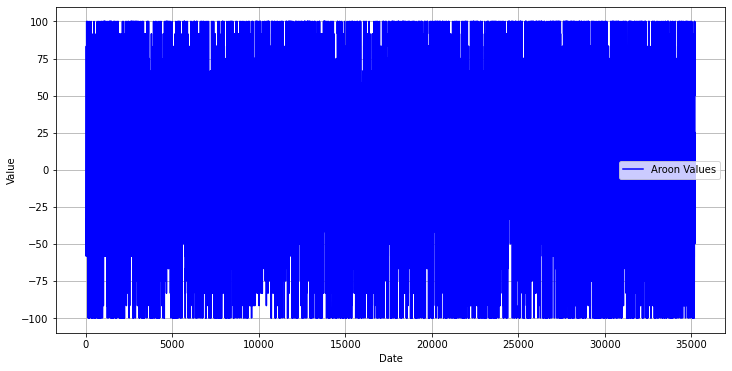

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from ta.trend import AroonIndicator

# Assuming you have initial_df already defined with a 'Close' column
# Calculate the RSI indicator for initial_df
aroon = AroonIndicator( high = final_df['high'] , low = final_df['low'] , window = 12 , fillna = False)

# Access the RSI values
aroon_vals = aroon.aroon_indicator()

final_df['aroon_vals'] = aroon_vals
final_df['aroon_sig'] = 0
for i in range(len(aroon_vals)):
  if( np.isnan(aroon_vals[i])):
    final_df['aroon_sig'][i] = 0
  elif(aroon_vals[i] > 0 ):
    final_df['aroon_sig'][i] = 1
  else:
    final_df['aroon_sig'][i] = -1
print(final_df)


# Plot the RSI indicator
plt.figure(figsize=(12, 6))
plt.plot(final_df.index, final_df['aroon_vals'], label='Aroon Values', color='blue')

plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# OBV

In [4]:
#OBV
from ta.utils import dropna
from ta.volume import OnBalanceVolumeIndicator

# Initialize On Balance Volume Indicator
indicator_obv = OnBalanceVolumeIndicator(close=final_df["close"],volume=final_df["volume"])
curr_sig=0
closed=True
final_df['obv_values'] = indicator_obv.on_balance_volume()
threshold = 100000 # Value threshold
signals_obv=[]
window_size=100
#ema = exponential moving average
final_df["obv_ema"] = final_df['obv_values'].ewm(span=200, adjust=False).mean()
for i in range(len(final_df)):
    if final_df.iloc[i].isna().any():
        signals_obv.append(0)  # Not enough data for the rolling window
    else:
        '''
        window_start = i - (window_size // 2)  # 50 hours before
        window_end = i + (window_size // 2)  # 50 hours after
        window_values = final_df['obv_values'].iloc[window_start:window_end]
        diff = window_values.iloc[-1] - window_values.iloc[0]
        '''
        long_entry=final_df['obv_values'].iloc[i]>final_df['obv_ema'].iloc[i]
        long_exit=final_df['obv_values'].iloc[i]<final_df['obv_ema'].iloc[i]
        short_entry=long_exit
        short_exit=long_entry
        if long_entry or short_exit:
            signals_obv.append(1)
            '''
            if long_entry and closed==True:
                #previous trade closed, can open new one
                signals_obv.append(1)
                closed=False
                curr_sig=1
            else:
                if short_exit and curr_sig==-1:
                    closed=True
                    curr_sig=0
                    signals_obv.append(1)
                else:
                    signals_obv.append(0)'''
          # set -1
        elif short_entry or long_exit:
            signals_obv.append(-1)
            '''
            if short_entry and closed==True:
                signals_obv.append(-1)
                closed=False
                curr_sig=-1
            else:
                if long_exit and curr_sig==1:
                    closed=True
                    curr_sig=0
                    signals_obv.append(-1)
                else:
                    signals_obv.append(0)'''
        else:
            signals_obv.append(0)
final_df["obv_sig"]=signals_obv
final_signals_obv=pd.DataFrame(signals_obv)
#final_signals_obv.to_csv("obv_outputtttt.csv")

# Ichimoku


In [5]:
import pandas_ta as ta
def ichimoku(data):
  ichi = ta.ichimoku(data['high'], data['low'], data['close'])
  data = pd.concat([data, ichi[0]], axis=1)
  return data
def ichi_long_entry(data,bar):
  if  data["close"].iloc[bar]>max(data["ISA_9"].iloc[bar], data["ISB_26"].iloc[bar]):
    return True
  else:
    return False

def ichi_long_exit(data,bar):
  if (data["ITS_9"].iloc[bar]<data["IKS_26"].iloc[bar] and data["ITS_9"].iloc[bar-1]>=data["IKS_26"].iloc[bar-1]):
    return True
  else:
    return False

def ichi_short_entry(data,bar):
  if  data["close"].iloc[bar]<min(data["ISA_9"].iloc[bar], data["ISB_26"].iloc[bar]) :
    return True
  else:
    return False

def ichi_short_exit(data,bar):
  if (data["ITS_9"].iloc[bar]>data["IKS_26"].iloc[bar] and data["ITS_9"].iloc[bar-1]<=data["IKS_26"].iloc[bar-1]):
    return True
  else:
    return False




In [6]:
final_df=ichimoku(final_df)[:35208]
print((final_df.columns))

Index(['datetime', 'open', 'high', 'low', 'close', 'volume', 'macd_vals',
       'macd_sig', 'aroon_vals', 'aroon_sig', 'obv_values', 'obv_ema',
       'obv_sig', 'ISA_9', 'ISB_26', 'ITS_9', 'IKS_26', 'ICS_26'],
      dtype='object')


In [7]:
#ichimoku signals
signals_ichi=[0]


curr_sig=0
closed=True
    #### set conditions for long_entry and long_exit
for i in range(1,len(final_df)):
    if final_df.iloc[i].isna().any():
        signals_ichi.append(0)

    else:
        long_entry=ichi_long_entry(final_df,i)
        long_exit=ichi_long_exit(final_df,i)
        short_entry=ichi_short_entry(final_df,i)
        short_exit=ichi_short_exit(final_df,i)
        if long_entry or short_exit:
              #go long
              signals_ichi.append(1)
              '''

              if long_entry and closed==True:
                  #previous trade closed, can open new one
                  signals_ichi.append(1)
                  closed=False
                  curr_sig=1
              else:
                  if short_exit and curr_sig==-1:
                      closed=True
                      curr_sig=0
                      signals_ichi.append(1)
                  else:
                      signals_ichi.append(0)'''
          # set -1
        elif short_entry or long_exit:
              signals_ichi.append(-1)
              '''

              if short_entry and closed==True:
                  signals_ichi.append(-1)
                  #print("no")
                  closed=False
                  curr_sig=-1
              else:
                  if long_exit and curr_sig==1:
                      closed=True
                      curr_sig=0
                      signals_ichi.append(-1)
                      #print("no")
                  else:
                      signals_ichi.append(0)'''
        else:
            signals_ichi.append(0)
final_df["ichimoku_sig"]=signals_ichi






In [8]:
data_ichi=pd.DataFrame(signals_ichi)
data_ichi["signals"]=signals_ichi
data_ichi.to_csv("ichimokusignals.csv")

In [9]:
#bollinger bands
from ta.utils import dropna
from ta.volatility import BollingerBands

# Initialize Bollinger Bands Indicator
indicator_bb = BollingerBands(close=final_df["close"], window=20, window_dev=2)
curr_sig=0
closed=True
final_df['bb_bbm_vals'] = indicator_bb.bollinger_mavg()
final_df['bb_bbh_vals'] = indicator_bb.bollinger_hband()
final_df['bb_bbl_vals'] = indicator_bb.bollinger_lband()
final_df['bb_bbhi'] = indicator_bb.bollinger_hband_indicator()
# Add Bollinger Band low indicator
final_df['bb_bbli'] = indicator_bb.bollinger_lband_indicator()
signals_bb=[]
for i in range(len(final_df)):
    if final_df.iloc[i].isna().any():
        signals_bb.append(0)

    else:
        long_entry=final_df['bb_bbhi'].iloc[i]
        long_exit=final_df["bb_bbli"].iloc[i]
        short_entry=long_exit
        short_exit=long_entry
        if long_entry or short_exit:
              signals_bb.append(1)
              '''
              #go long
              if long_entry and closed==True:
                  #previous trade closed, can open new one
                  signals_bb.append(1)
                  closed=False
                  curr_sig=1
              else:
                  if short_exit and curr_sig==-1:
                      closed=True
                      curr_sig=0
                      signals_bb.append(1)
                  else:
                      signals_bb.append(0)'''
          # set -1
        elif short_entry or long_exit:
              signals_bb.append(-1)
              '''
              if short_entry and closed==True:
                  signals_bb.append(-1)
                  closed=False
                  curr_sig=-1
              else:
                  if long_exit and curr_sig==1:
                      closed=True
                      curr_sig=0
                      signals_bb.append(-1)
                  else:
                      signals_bb.append(0)'''
        else:
            signals_bb.append(0)
final_df["bb_sig"]=signals_bb
final_signals_bb=pd.DataFrame(signals_bb)
final_signals_bb.to_csv("bb_outputtttt.csv")





In [10]:
import pandas as pd
import ta

tester = ta.trend.ADXIndicator(final_df['high'], final_df['low'], final_df['close'])
final_df['adx'] = tester.adx() #Average Directional Index
final_df['pdi'] = tester.adx_pos() # + Directional Indicator
final_df['ndi'] = tester.adx_neg() # - Directional Indicator
adx_signals=[]
curr_sig=0
closed=True
#### set conditions for long_entry and long_exit
for bar in range(len(final_df)):
    if final_df.iloc[bar].isna().any():
        adx_signals.append(0)

    else:
        long_entry = final_df['pdi'][bar] > final_df['ndi'][bar]
        long_exit = final_df['pdi'][bar] < final_df['ndi'][bar]
        short_entry = final_df['pdi'][bar] < final_df['ndi'][bar]
        short_exit = final_df['pdi'][bar] > final_df['ndi'][bar]

        if long_entry or short_exit:
            adx_signals.append(1)
            '''
            if long_entry and closed==True:
                #previous trade closed, can open new one
                adx_signals.append(1)
                closed=False
                curr_sig=1
            else:
                if short_exit and curr_sig==-1:
                    closed=True
                    curr_sig=0
                    adx_signals.append(1)
                else:
                    adx_signals.append(0)'''
        elif short_entry or long_exit:
            adx_signals.append(-1)
            '''
            if short_entry and closed==True:
                adx_signals.append(-1)
                closed=False
                curr_sig=-1
            else:
                if long_exit and curr_sig==1:
                    closed=True
                    curr_sig=0
                    adx_signals.append(-1)
                else:
                    adx_signals.append(0)'''
        else:
            adx_signals.append(0)
final_df['adx_sig'] = adx_signals

In [11]:
def rsi_long_entry(rsi_value):
    if (rsi_value <= 25 and rsi_value > 12.5) or rsi_value > 87.5:
        return True
    return False

def rsi_long_exit(rsi_value):
    if (rsi_value <= 87.5 and rsi_value > 75) or (rsi_value <= 12.5) or (rsi_value >= 25 and rsi_value < 75):
        return True
    return False

def rsi_short_entry(rsi_value):
    if (rsi_value <= 87.5 and rsi_value > 75) or rsi_value <= 12.5:
        return True
    return False

def rsi_short_exit(rsi_value):
    if (rsi_value <= 25 and rsi_value > 12.5) or (rsi_value > 87.5) or (rsi_value >= 25 and rsi_value < 75):
        return True
    return False


In [12]:
import ta

tester = ta.momentum.RSIIndicator(close=final_df['close'], window=14, fillna=False)
rsi_values = tester.rsi()
final_df['rsi_values'] = rsi_values
rsi_signals=[]
curr_sig=0
closed=True
#### set conditions for long_entry and long_exit
for bar in range(len(final_df)):
    if final_df.iloc[bar].isna().any():
        rsi_signals.append(0)

    else:
        long_entry = rsi_long_entry(rsi_values[bar])
        long_exit = rsi_long_exit(rsi_values[bar])
        short_entry = rsi_short_entry(rsi_values[bar])
        short_exit = rsi_short_exit(rsi_values[bar])

        if long_entry or short_exit:
            rsi_signals.append(1)
            '''
            if long_entry and closed==True:
                #previous trade closed, can open new one
                rsi_signals.append(1)
                closed=False
                curr_sig=1
            else:
                if short_exit and curr_sig==-1:
                    closed=True
                    curr_sig=0
                    rsi_signals.append(1)
                else:
                    rsi_signals.append(0)'''
        # set -1
        elif short_entry or long_exit:
            rsi_signals.append(-1)
            '''
            if short_entry and closed==True:
                rsi_signals.append(-1)
                closed=False
                curr_sig=-1
            else:
                if long_exit and curr_sig==1:
                    closed=True
                    curr_sig=0
                    rsi_signals.append(-1)
                else:
                    rsi_signals.append(0)'''
        else:
            rsi_signals.append(0)
final_df['rsi_sig'] = rsi_signals

In [13]:
import talib
atr = talib.ATR(final_df['high'], final_df['low'], final_df['close'], timeperiod=14)

# Assign ATR values to a new column in your DataFrame
final_df['atr'] = atr
#stop loss using atr values
def long_stop_loss(bar,long_entry_price):
    if long_entry_price==None:
        return False
    elif final_df["close"].iloc[bar]<long_entry_price-2*final_df["atr"].iloc[bar]:
        return True
    else:
        return False
    

def short_stop_loss(bar,short_entry_price):
    if short_entry_price==None:
        return False
    elif final_df["close"].iloc[bar]>short_entry_price+2*final_df["atr"].iloc[bar]:
        return True
    else:
        return False

In [23]:

signals_final=[]
temp=[]
curr_sig=0
closed=True
import statistics
from statistics import mode
    #### set conditions for long_entry and long_exit
print(len(final_df))
for i in range(len(final_df)):
    if final_df.iloc[i].isna().any():
        signals_final.append(0)

    else:
        temp=[final_df["rsi_sig"].iloc[i],final_df["adx_sig"].iloc[i],final_df["macd_sig"].iloc[i],final_df["bb_sig"].iloc[i],final_df["obv_sig"].iloc[i],final_df["ichimoku_sig"].iloc[i],final_df["aroon_sig"].iloc[i]]
        dic={}
        long_entry=0
        short_exit=0
        short_entry=0
        long_exit=0
        for j in [-1,0,1]:
            dic[j]=0
        for j in temp:
            dic[j]+=1
        if dic[-1]>=4:
          short_entry=True
          long_exit=True
          long_entry=False
          short_exit=False
        elif dic[1]>=4:
          long_entry=True
          long_exit=False
          short_entry=False
          short_exit=True
        else:
          long_entry=False
          long_exit=False
          short_entry=False
          short_exit=False
        long_entry_price=None
        short_entry_price=None

        if long_entry or short_exit:
              #go long
              if long_entry and closed==True:
                  #previous trade closed, can open new one
                  signals_final.append(1)
                  long_entry_price=final_df["close"].iloc[i]
                  closed=False
                  curr_sig=1
              else:
                  if (short_exit or short_stop_loss(i,short_entry_price))and curr_sig==-1:
                      closed=True
                      curr_sig=0
                      signals_final.append(1)
                      short_entry_price=None
                  else:
                      signals_final.append(0)
          # set -1
        elif short_entry or long_exit:
              if short_entry and closed==True:
                  signals_final.append(-1)
                  short_entry_price=final_df["close"].iloc[i]
                  closed=False
                  curr_sig=-1
              else:
                  if (long_exit or long_stop_loss(i,long_entry_price)) and curr_sig==1:
                      closed=True
                      curr_sig=0
                      signals_final.append(-1)
                      long_entry_price=None
                  else:
                      signals_final.append(0)
        else:
            signals_final.append(0)


35208


In [24]:
#store indices of all non zero values in a list

indices = []
for i in range(len(signals_final)):
  if signals_final[i] != 0:
    indices.append(i)


In [25]:
stop_loss_percentage = 0.06
'''
def stop_loss_condition(keys, signals, df):
  i = 0
  while(i < len(keys)):
    if signals[i] == 1 and signals[i+1] == -1:
      rolling_max = df['close'][keys[i]]
      for j in range(keys[i]+1, keys[i+1]):
        if df['close'][j] > rolling_max:
          rolling_max = df['close'][j]
        if df['close'][j] <= rolling_max*(1-stop_loss_percentage):
          signals[j] = -1
          signals[i+1] = 0
          break
    if signals[i] == -1 and signals[i+1] == 1:
      rolling_min = df['close'][keys[i]]
      for j in range(keys[i]+1, keys[i+1]):
        if df['close'][j] < rolling_min:
          rolling_min = df['close'][j]
        if df['close'][j] >= rolling_min*(1+stop_loss_percentage):
          signals[j] = 1
          signals[i+1] = 0
          break
    i += 2
  return signals
'''


"\ndef stop_loss_condition(keys, signals, df):\n  i = 0\n  while(i < len(keys)):\n    if signals[i] == 1 and signals[i+1] == -1:\n      rolling_max = df['close'][keys[i]]\n      for j in range(keys[i]+1, keys[i+1]):\n        if df['close'][j] > rolling_max:\n          rolling_max = df['close'][j]\n        if df['close'][j] <= rolling_max*(1-stop_loss_percentage):\n          signals[j] = -1\n          signals[i+1] = 0\n          break\n    if signals[i] == -1 and signals[i+1] == 1:\n      rolling_min = df['close'][keys[i]]\n      for j in range(keys[i]+1, keys[i+1]):\n        if df['close'][j] < rolling_min:\n          rolling_min = df['close'][j]\n        if df['close'][j] >= rolling_min*(1+stop_loss_percentage):\n          signals[j] = 1\n          signals[i+1] = 0\n          break\n    i += 2\n  return signals\n"

In [26]:
count1=0
count_minus1=0
count_zero=0

for i in signals_final:
    if i==1:
        count1+=1
    elif i==-1:
        count_minus1+=1
    else:
        count_zero+=1

print(count1)
print(count_minus1)
print(count_zero)
signals_final1 = signals_final
#stop_loss_condition(indices, signals_final1, final_df)

1412
1413
32383


In [27]:
count1=0
count_minus1=0
count_zero=0

for i in signals_final:
    if i==1:
        count1+=1
    elif i==-1:
        count_minus1+=1
    else:
        count_zero+=1

print(count1)
print(count_minus1)
print(count_zero)


1412
1413
32383


In [28]:
final_df["final_sig"]=signals_final1

In [29]:
final_df

,datetime,open,high,low,close,volume,macd_vals,macd_sig,aroon_vals,aroon_sig,...,bb_bbli,bb_sig,adx,pdi,ndi,adx_sig,rsi_values,rsi_sig,atr,final_sig
0,2018-01-01 05:30:00,13715.65,13715.65,13400.01,13529.01,443.356199,NaN,0,NaN,0,...,0.0,0,0.000000,0.000000,0.000000,0,NaN,0,NaN,0
1,2018-01-01 06:30:00,13528.99,13595.89,13155.38,13203.06,383.697006,NaN,0,NaN,0,...,0.0,0,0.000000,0.000000,0.000000,0,NaN,0,NaN,0
2,2018-01-01 07:30:00,13203.00,13418.43,13200.00,13330.18,429.064572,NaN,0,NaN,0,...,0.0,0,0.000000,0.000000,0.000000,0,NaN,0,NaN,0
3,2018-01-01 08:30:00,13330.26,13611.27,13290.00,13410.03,420.087030,NaN,0,NaN,0,...,0.0,0,0.000000,0.000000,0.000000,0,NaN,0,NaN,0
4,2018-01-01 09:30:00,13434.98,13623.29,13322.15,13601.01,340.807329,NaN,0,NaN,0,...,0.0,0,0.000000,0.000000,0.000000,0,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.601780,78.169130,1,25.0,1,...,0.0,0,17.104235,22.890793,11.469653,0,62.352113,0,521.606389,0
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.103800,74.542038,1,25.0,1,...,0.0,0,18.062861,22.299025,11.869180,0,59.368552,0,497.202361,0
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.859930,71.553784,1,25.0,1,...,0.0,0,18.761451,21.699012,12.247301,0,60.152924,0,474.454335,0
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.142010,67.839928,1,25.0,1,...,0.0,0,19.667713,22.561774,11.765991,0,60.399616,0,458.586883,0


In [30]:
final_signals_values=pd.DataFrame(signals_final)
final_signals_values['signals']=signals_final
final_signals_values.to_csv("final.csv")